# Chapter-01. Tensor 概念和创建

## 【章节目标】

理解tensor概念  
理解tesnor的shape、dim等属性概念  
掌握创建tensor的方法和api  

## 【章节内容】

### Tensor概念及其属性

#### 1）Tensor概念

张量（tensor）是多维数组，目的是把向量、矩阵推向更高的维度  
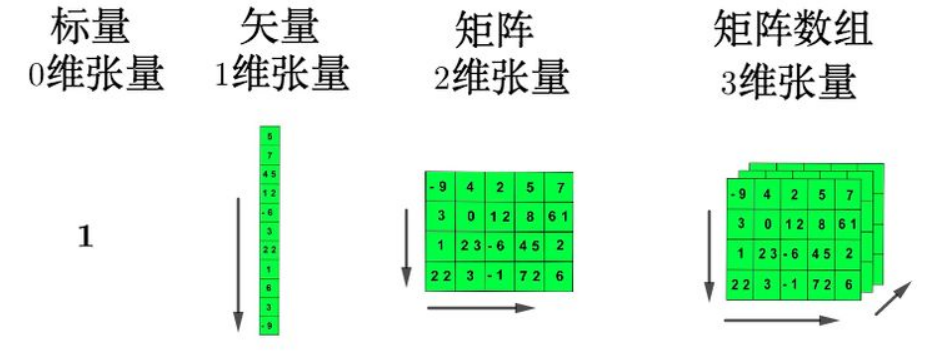

把三维张量画成一个立方体,多维的张量就可以这么理解：  
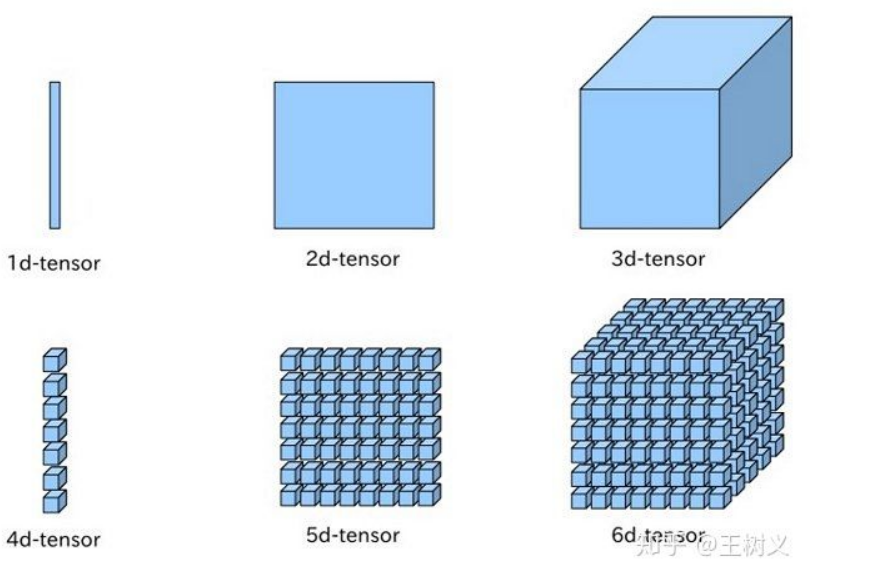  
从数据结构上来看，张量就是多维数组。

#### 2）rank/dim/axis
就是有几个维度，也相当与有几个括号，也是shape元组的长度，rank的idx计数都是从外向里，从大到小，也就是shape的排列方式。 
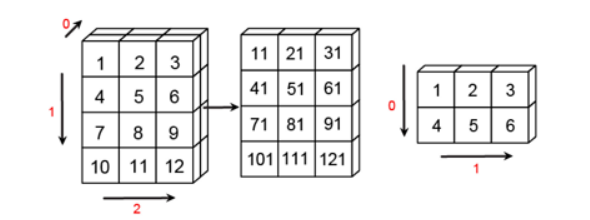  
图中数字表示rank的idx，箭头表示idx的方向。

***dim：代码实现***

In [1]:
import torch
a = torch.arange(1, 25).reshape(2, 4, 3)
a

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18],
         [19, 20, 21],
         [22, 23, 24]]])

In [2]:
a.shape, a.dim()

(torch.Size([2, 4, 3]), 3)

#### 3）shape的理解

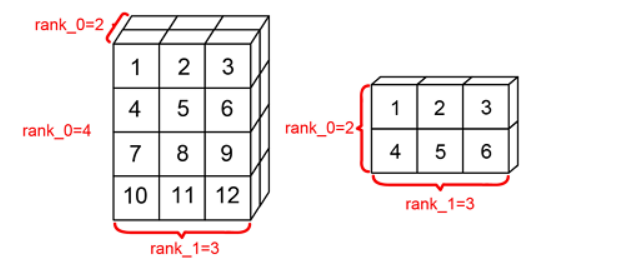  

从后往前看：最后一维表示单位向量有几个元素，倒数第二维则是有几个单位向量，依次向前。  

从前向后看：第一维表示几个后几维组成的张量，第二维表示几个后几维组成的张量。

***shape理解:代码实现***

In [3]:
a.shape

torch.Size([2, 4, 3])

In [4]:
b = torch.arange(1, 7).reshape(2, 3)
b

tensor([[1, 2, 3],
        [4, 5, 6]])

In [5]:
b.shape

torch.Size([2, 3])

#### 4） Tensor的属性

dtype: 张量的数据类型，如torch.FloatTensor, torch.cuda.FloatTensor  
shape: 张量的形状，如(64, 3, 224, 224)  
device: 张量所在设备，GPU/CPU，是加速的关键  

***Tensor属性：代码实现***

In [6]:
a.shape

torch.Size([2, 4, 3])

In [7]:
a.dtype

torch.int64

In [8]:
a.device

device(type='cpu')

### Tensor的创建
#### 1）直接创建
##### 1.1）torch.tensor()

功能：从data创建tensor  
  
data: 数据,可以是list,numpy  
dtype: 数据类型，默认与data的一致  
device:所在设备, cuda/cpu  
requires_grad：是否需要梯度  
pin_memory：是否存于锁页内存  

代码演示:  

In [9]:
a = torch.tensor(2)
a

tensor(2)

In [10]:
a.dim(), a.shape

(0, torch.Size([]))

In [11]:
type(a.data)

torch.Tensor

In [13]:
a.dtype

torch.int64

In [14]:
a.requires_grad

False

In [16]:
a.numpy() # 底层封装了numpy的ndarray

array(2, dtype=int64)

In [18]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype = torch.float32)
b.shape, b.dtype, b.dim()

(torch.Size([2, 3]), torch.float32, 2)

In [19]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype = torch.float32, device = 'cuda')

##### 1.2） torch.from_numpy(ndarray)
  
功能：从numpy创建tensor  
  
> 注意事项：从torch.from_numpy创建的tensor于原ndarray共享内存，当修改其中一个的数据，另外一个也将会被改动
> 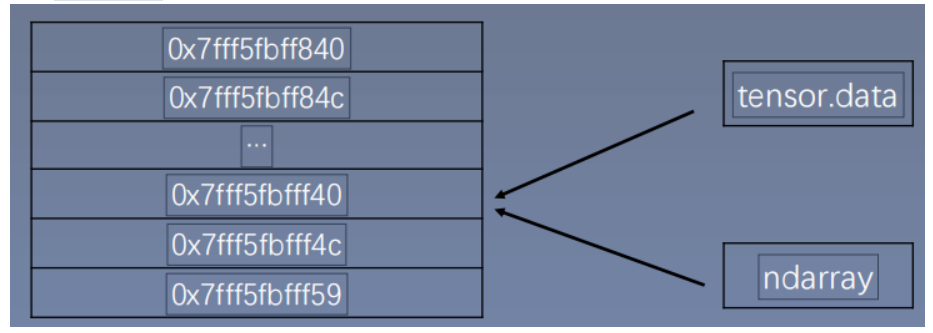

代码演示：

In [29]:
import numpy as np
arr = np.array([1, 2, 3]) # 默认是int32
t = torch.from_numpy(arr)
t

tensor([1, 2, 3], dtype=torch.int32)

In [30]:
# 修改numpy的array
arr[0] = 5
t # tensor指向的数据也被修改

tensor([5, 2, 3], dtype=torch.int32)

#### 2）依据数值创建
##### 2.1） torch.zeros()
功能：依size创建全0张量

size: 张量的形状, 如(3, 3)、(3, 224,224)  
out: 输出的张量  
layout:内存中布局形式, 有strided,sparse_coo等  
device:所在设备, cuda/cpu  
requires_grad：是否需要梯度  
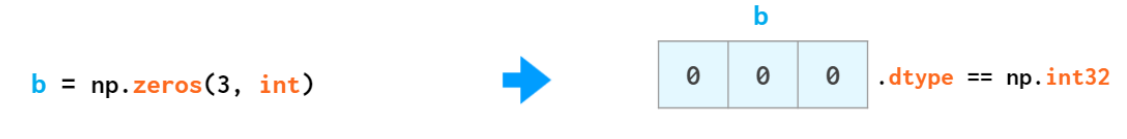

代码演示：

In [31]:
t2 = torch.zeros([3, 3])
t2

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [32]:
t2.dtype

torch.float32

In [33]:
torch.zeros([3], out = t) # 等于 t=torch.zeros([3])
t

tensor([0, 0, 0], dtype=torch.int32)

In [34]:
arr # arr也改变

array([0, 0, 0])

##### 2.2）torch.zeros_like()

功能：依input形状创建全0张量

intput: 创建与input同形状的全0张量
dtype: 数据类型
layout:内存中布局形式
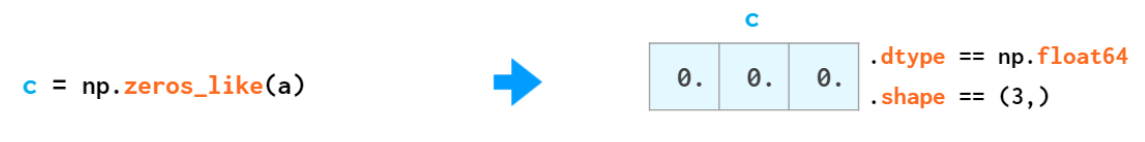

代码演示：

In [35]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]])
torch.zeros_like(b)

tensor([[0, 0, 0],
        [0, 0, 0]])

In [36]:
b # b并没有修改

tensor([[1, 2, 3],
        [4, 5, 6]])

##### 2.3） torch.ones() & torch.ones_like()
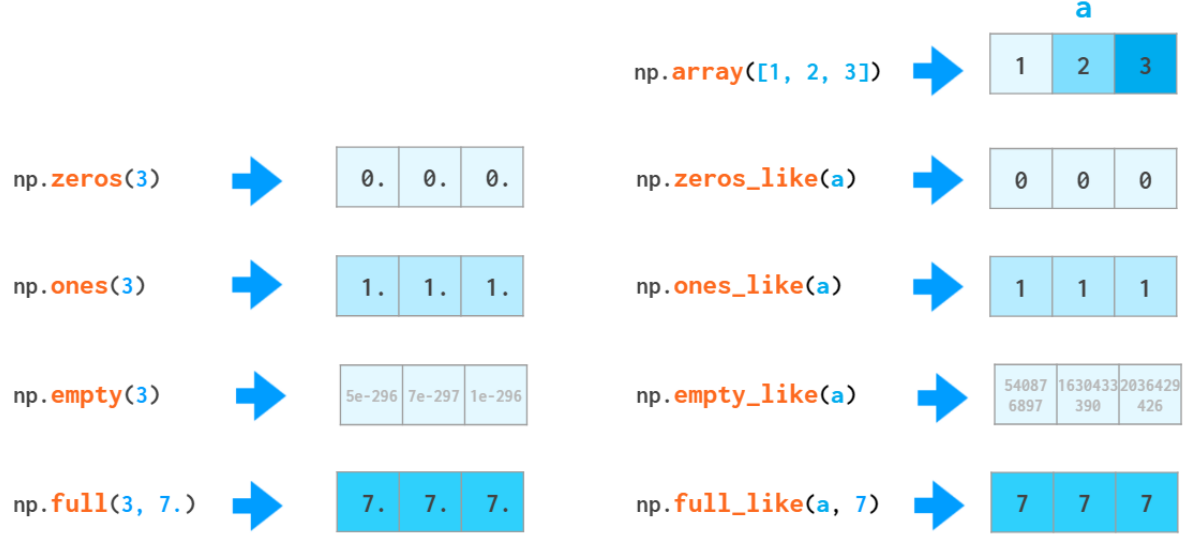

In [37]:
torch.ones([2, 3])

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [38]:
torch.ones_like(b)

tensor([[1, 1, 1],
        [1, 1, 1]])

##### 2.4） torch.full() & torch.full_like()

In [39]:
torch.full([2, 3], fill_value = 2)

tensor([[2, 2, 2],
        [2, 2, 2]])

In [40]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]])
torch.full_like(b, fill_value = 2)

tensor([[2, 2, 2],
        [2, 2, 2]])

##### 2.5） torch.arange()
- 功能：创建等差的1维张量  
- 注意事项：数值区间为[start, end)  
- 参数  
    - start: 数列起始值  
    - end: 数列“结束值”  
    - step: 数列公差，默认为1  

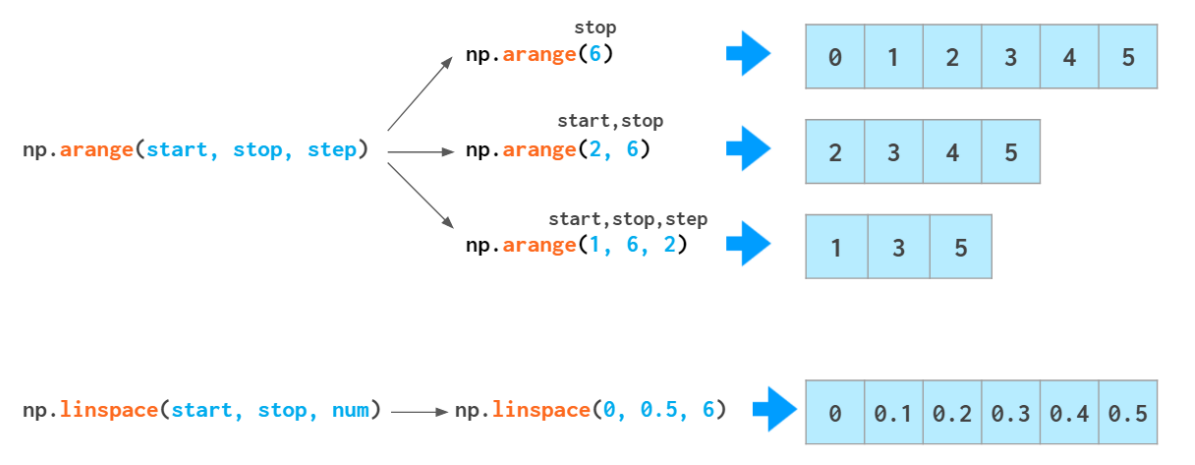  
代码演示：

In [41]:
torch.arange(1, 10)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [42]:
torch.arange(1, 10, 2)

tensor([1, 3, 5, 7, 9])

##### 2.6） torch.linspace()
- 功能：创建均分的1维张量
- 注意事项：数值区间为[start, end]
- 参数：
    - start: 数列起始值
    - end: 数列结束值
    - steps: 数列长度,默认100  

代码演示：

In [45]:
torch.linspace(1, 10, 10)

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

##### 2.7）torch.logspace()
- 功能：创建对数均分的1维张量
- 注意事项：长度为steps, 底为base
- 参数
    - start : 数列起始
    - end : 数列结束值
    - steps: 数列长度
    - base : 对数函数的底，默认为10

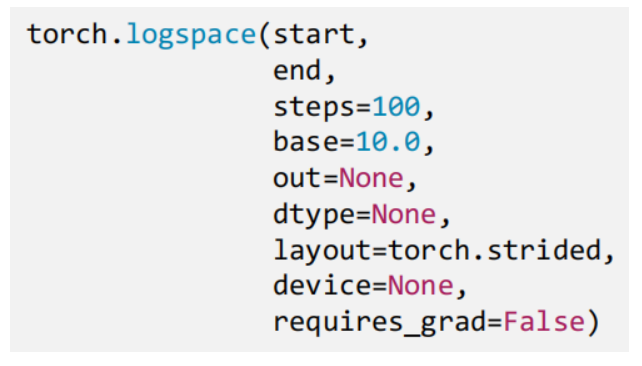  
代码演示：

In [46]:
torch.logspace(-2, 2, 5) # 取值 -2,-1,0,1,2 默认以10为底

tensor([1.0000e-02, 1.0000e-01, 1.0000e+00, 1.0000e+01, 1.0000e+02])

In [47]:
torch.logspace(-2, 2, 5, 2)

tensor([0.2500, 0.5000, 1.0000, 2.0000, 4.0000])

##### 2.8） torch.eye()
- 功能：创建单位对角矩阵（ 2维张量）
- 注意事项：默认为方阵
    - n: 矩阵行数
    - m : 矩阵列数
    
代码演示：

In [48]:
torch.eye(3, 3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [49]:
torch.eye(3, 4)

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]])

#### 3） 依概率分布创建张量
##### 3.1） torch.normal()
功能：生成正态分布（高斯分布）
- mean : 均值
- std : 标准差
- size:tensor形状   

四种模式：  
- mean为标量，std为标量
- mean为标量，std为张量
- mean为张量，std为标量
- mean为张量，std为张量  

代码演示：

In [53]:
# mean为标量，std为标量  此时size必须指定
torch.normal(0, 1, size = [2, 3])

tensor([[-0.2269, -0.6263,  0.5660],
        [ 0.7889, -0.3328, -0.4995]])

In [ ]:
#mean为标量，std为张量    
#此时所有样本std不同，共享mean
#tensor的shape=std的shape    此时不能指定size   std取值[1,2,3,4]
torch.normal(mean = 0, std = torch.arange(1, 5).to(torch.float32))

tensor([ 1.0266, -5.1646,  1.2969,  2.8111])

In [56]:
#mean为张量，std为标量    
#此时所有样本mean不同，共享std
#tensor的shape=mean的shape    此时不能指定size 均值取值[1,2,3,4]
torch.normal(mean = torch.arange(1, 5).to(torch.float32), std = 0.2)

tensor([0.9992, 2.3071, 3.2056, 3.8609])

In [57]:
#mean为张量，std为张量    
#此时所有样本mean不同，共享std
#tensor的shape=mean的shape    此时不能指定size
torch.normal(mean = torch.arange(1, 5).to(torch.float32), std = torch.arange(1, 5))

tensor([ 0.2564, -1.2975,  4.9287, 11.8425])

In [58]:
#mean和std适用广播法则  mean:shape[4] -->[1,4] -->[5,4]  std:shape[5,4]
torch.normal(mean = torch.arange(1, 5).to(torch.float32), std = torch.arange(1, 21).reshape(5, 4))

tensor([[  1.6127,  -1.0485,   4.8632,   2.0911],
        [ -5.9896,   3.6114,   1.2089,  -4.1350],
        [  1.2752,   9.4592,  12.4558,   8.6176],
        [ -0.9248,  -9.9915, -11.8362,   2.3807],
        [-12.0821,  15.9887,  -9.8936,  25.2929]])

##### 3.2） torch.randn() & torch.randn_like()
- 功能：生成标准正态分布

    - size : 张量的形状

In [59]:
torch.randn([2, 3])

tensor([[-0.1980, -0.4675, -1.3223],
        [ 2.2134, -0.2366, -0.6933]])

In [62]:
# b = torch.tensor([[1, 2, 3], [4, 5, 6]]) #报错"norma_cpu" not implemented for 'Long'
b = torch.tensor([[1, 2, 3], [4, 5, 6]]).to(torch.float32)
torch.randn_like(b) #拷贝shape和dtype

tensor([[-0.6612,  2.3953, -0.4807],
        [ 0.7965, -0.3269, -1.8393]])

##### 3.3） torch.rand() & torch.rand_like()
- 功能：在区间[0, 1)上，生成均匀分布

In [63]:
torch.rand([3])

tensor([0.9822, 0.1422, 0.9534])

In [64]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]]).to(torch.float32)
torch.rand_like(b)

tensor([[0.8347, 0.5139, 0.4217],
        [0.1593, 0.8003, 0.6057]])

##### 3.4） torch.randint() & torch.randint_like()
功能：区间[low, high)生成整数均匀分布

    - low：最小值 默认0
    - high：最大值 默认1
    - size:形状

In [65]:
torch.randint(1, 10, [2, 3])

tensor([[1, 9, 9],
        [3, 5, 4]])

In [67]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]])
torch.randint_like(b, 1, 10)

tensor([[6, 9, 7],
        [1, 5, 2]])

##### 3.5） torch.randperm()
功能：生成生成从0到n-1的随机排列，一般用来对一个有顺序得序列进行打乱

- n : 张量的长度

In [69]:
a = torch.randint(1, 10, size = [10])
a

tensor([8, 1, 1, 1, 2, 2, 8, 7, 7, 6])

In [70]:
index = torch.randperm(10)
a[index] # 乱序下标访问

tensor([1, 7, 6, 2, 1, 2, 1, 7, 8, 8])

In [71]:
torch.randperm(10)

tensor([3, 0, 5, 9, 4, 1, 8, 2, 7, 6])

##### 3.6） torch.bernoulli()
功能：以input为概率，生成伯努力分布（0-1分布，两点分布）

- input : 概率值,必须是tensor

In [72]:
torch.bernoulli(0.6) # 参数必须是tensor

TypeError: bernoulli(): argument 'input' (position 1) must be Tensor, not float

In [73]:
torch.bernoulli(torch.tensor(0.6))

tensor(1.)

In [74]:
torch.bernoulli(torch.tensor([0.6, 0.7]))

tensor([0., 1.])